<a href="https://colab.research.google.com/github/sujitx-vs/Deep-Neural-Networks---PGCP_AI/blob/main/DNN_Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.data import Dataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Loading Data

In [2]:
iris = load_iris()
X = iris.data
Y = iris.target

In [3]:
x = pd.DataFrame(X)

print(x.info())
print()
y = pd.DataFrame(Y)
print(y.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


##  Training, Testing Split & Scaling


In [4]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

### Sequential Keras Model
- A Keras Sequential model is a linear stack of neural network layers. It is the simplest way to build a deep learning model, where data flows in a strict, one-way sequence—entering the first layer, passing through each hidden layer one by one, and exiting through the final output layer.

In [5]:
model = keras.Sequential([
    layers.Dense(16,activation='relu',input_shape=(4,)),
    layers.Dense(8,activation='relu'),
    layers.Dense(6,activation='relu'),
    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- input layer is the one defined with input_shape 4
- first Layer with 8 neurons is the hidden layer
- second one with 6 neurons is the hidden layer
- third one with 3 neurons is the output layer
- > this is a basic simple sequential model.

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

- > model.summary
- shows the blueprint of the whole model.

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train,Y_train,epochs=50,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.4062 - loss: 1.0534 - val_accuracy: 0.2500 - val_loss: 1.0523
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4375 - loss: 1.0150 - val_accuracy: 0.2917 - val_loss: 1.0112
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4792 - loss: 0.9786 - val_accuracy: 0.3750 - val_loss: 0.9719
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5312 - loss: 0.9433 - val_accuracy: 0.6250 - val_loss: 0.9278
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5833 - loss: 0.9066 - val_accuracy: 0.7083 - val_loss: 0.8793
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6354 - loss: 0.8675 - val_accuracy: 0.7500 - val_loss: 0.8306
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7708 - loss: 0.8289 - val_accuracy: 0.9167 - val_loss: 0.7818
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8021 - loss: 0.7868 - val_accuracy: 0.9583 - val_loss: 0.7383

- > Compile
- Used Adam Optimizer - to adjust the weight after each epoch.
- Sparse Categorical CrossEntropy as the loss function - to measure how wrong the model predicting.
- Accuracy is used as the Matrix , that used to show after each epoch

- > Fit

- epoch - No of time model goes one complete pass through your entire dataset.

- batch_size - divided whole data into smaller chunks. Smaller chunks make learning faster and use less computer memory.

- validation_split -  Percent of data that of training data that is uesd to tests the model.

- verbose - tells Python to print out a live progress bar and stats on screen for every single epoch

## Model evaluvation

In [8]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.1843
Test accuracy: 1.0
Test loss: 0.18425707519054413


## Plotting the Results

/tmp/ipykernel_4416/2988003575.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Validation')


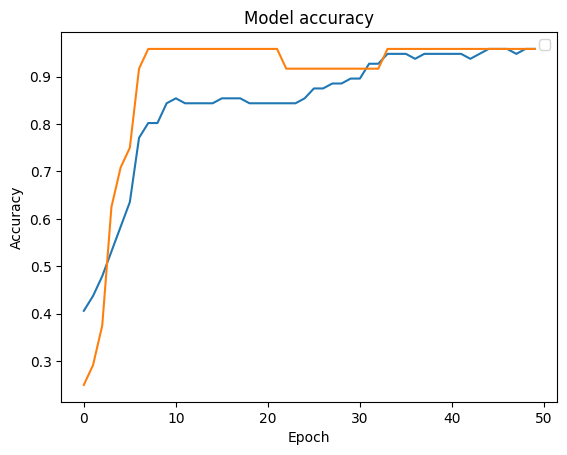

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend('Train', 'Validation')

#Diabetes

- New Dataset.

In [10]:
df = pd.read_excel('diabetes.xlsx')
df.head()

,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,DietType,Outcome
0,148,72,33.6,0.63,50,1,1
1,85,66,26.6,0.35,31,2,0
2,183,64,23.3,0.67,32,1,1
3,89,66,28.1,0.17,21,1,0
4,137,40,43.1,2.29,33,1,1


In [11]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [14]:
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5580 - loss: 0.6896 - val_accuracy: 0.6992 - val_loss: 0.6846
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6965 - loss: 0.6813 - val_accuracy: 0.7154 - val_loss: 0.6773
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7108 - loss: 0.6735 - val_accuracy: 0.7236 - val_loss: 0.6701
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7332 - loss: 0.6645 - val_accuracy: 0.7236 - val_loss: 0.6609
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7434 - loss: 0.6524 - val_accuracy: 0.7236 - val_loss: 0.6498
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7556 - loss: 0.6353 - val_accuracy: 0.7398 - val_loss: 0.6315
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7617 - loss: 0.6109 - val_accuracy: 0.7398 - val_loss: 0.6069
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7780 - loss: 0.5785 - val_accuracy: 0.7480 - 

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8312 - loss: 0.3468 
Test accuracy: 0.8311688303947449
Test loss: 0.34683147072792053


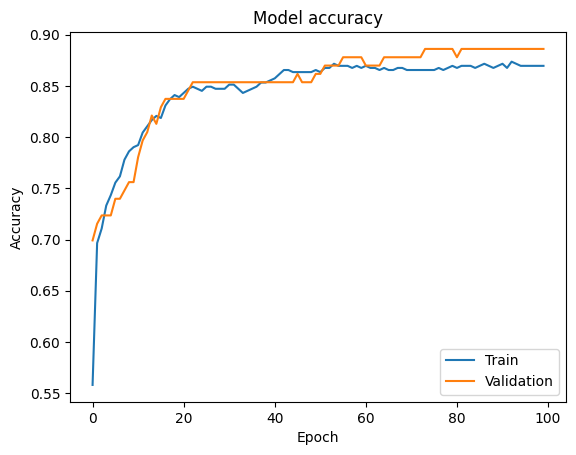

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

# Titianic

In [19]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

In [20]:
import seaborn as sns
df = sns.load_dataset('titanic')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [21]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features]
y = df['survived']

## Pipelining is used here.

In [22]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

Numerical and Categorical pipelines.

In [23]:
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

numerical and categorical features divided.

In [24]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [25]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [28]:
base_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
base_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
history_baseline = base_model.fit(X_train, y_train,validation_split=0.2, epochs=50,batch_size=32,verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4921 - loss: 0.7013 - val_accuracy: 0.6993 - val_loss: 0.6260
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7047 - loss: 0.6178 - val_accuracy: 0.6923 - val_loss: 0.5741
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7135 - loss: 0.5655 - val_accuracy: 0.7203 - val_loss: 0.5352
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7487 - loss: 0.5270 - val_accuracy: 0.8042 - val_loss: 0.5041
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7944 - loss: 0.4995 - val_accuracy: 0.8392 - val_loss: 0.4813
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8049 - loss: 0.4745 - val_accuracy: 0.8322 - val_loss: 0.4631
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8155 - loss: 0.4555 - val_accuracy: 0.8322 - val_loss: 0.4480
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8225 - loss: 0.4409 - val_accuracy: 0.8252 - val_loss

In [31]:
base_loss, base_acc = base_model.evaluate(X_test, y_test)

print("Base model Accuracy:", base_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7765 - loss: 0.4491 
Base model Accuracy: 0.7765362858772278


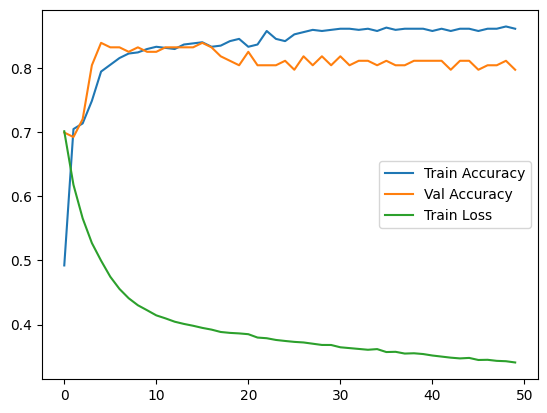

In [32]:
import matplotlib.pyplot as plt

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.legend()
plt.show()

## Model Comparison

In [33]:
def create_model(optimizer):

    model = keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [34]:
small_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.0001)
)

history_small_lr = small_lr_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4464 - loss: 0.6974 - val_accuracy: 0.5524 - val_loss: 0.6788
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5272 - loss: 0.6913 - val_accuracy: 0.6154 - val_loss: 0.6739
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5694 - loss: 0.6856 - val_accuracy: 0.6364 - val_loss: 0.6690
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5729 - loss: 0.6798 - val_accuracy: 0.6434 - val_loss: 0.6639
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6134 - loss: 0.6738 - val_accuracy: 0.6434 - val_loss: 0.6584
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6397 - loss: 0.6675 - val_accuracy: 0.6573 - val_loss: 0.6525
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6591 - loss: 0.6609 - val_accuracy: 0.6783 - val_loss: 0.6469
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6643 - loss: 0.6545 - val_accuracy: 0.6993 - val_loss

In [35]:
medium_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.001)
)
history_medium_lr = medium_lr_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5729 - loss: 0.6871 - val_accuracy: 0.5944 - val_loss: 0.6536
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6397 - loss: 0.6242 - val_accuracy: 0.6503 - val_loss: 0.6064
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7065 - loss: 0.5814 - val_accuracy: 0.6853 - val_loss: 0.5710
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7293 - loss: 0.5487 - val_accuracy: 0.7273 - val_loss: 0.5384
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7434 - loss: 0.5185 - val_accuracy: 0.7483 - val_loss: 0.5127
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7610 - loss: 0.4955 - val_accuracy: 0.7552 - val_loss: 0.4922
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7856 - loss: 0.4757 - val_accuracy: 0.7692 - val_loss: 0.4751
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8102 - loss: 0.4588 - val_accuracy: 0.7832 - val_lo

In [36]:
large_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.01)
)
history_large_lr = large_lr_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7575 - loss: 0.5198 - val_accuracy: 0.7692 - val_loss: 0.4863
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8137 - loss: 0.4366 - val_accuracy: 0.7972 - val_loss: 0.4581
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8225 - loss: 0.4034 - val_accuracy: 0.8042 - val_loss: 0.4909
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8330 - loss: 0.3998 - val_accuracy: 0.7832 - val_loss: 0.4650
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8559 - loss: 0.3778 - val_accuracy: 0.7902 - val_loss: 0.4764
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8594 - loss: 0.3622 - val_accuracy: 0.7972 - val_loss: 0.4832
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8594 - loss: 0.3593 - val_accuracy: 0.8042 - val_loss: 0.4824
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8612 - loss: 0.3517 - val_accuracy: 0.7762 - val_loss

In [37]:
# Evaluate models on the test set
loss_small_lr, acc_small_lr = small_lr_model.evaluate(X_test, y_test, verbose=0)
loss_medium_lr, acc_medium_lr = medium_lr_model.evaluate(X_test, y_test, verbose=0)
loss_large_lr, acc_large_lr = large_lr_model.evaluate(X_test, y_test, verbose=0)

print("Small LR Model Test Accuracy:",round(acc_small_lr,4))
print("Medium LR Model Test Accuracy:",round(acc_medium_lr,4))
print("Large LR Model Test Accuracy:",round(acc_large_lr,4))

Small LR Model Test Accuracy: 0.7542
Medium LR Model Test Accuracy: 0.7821
Large LR Model Test Accuracy: 0.7933


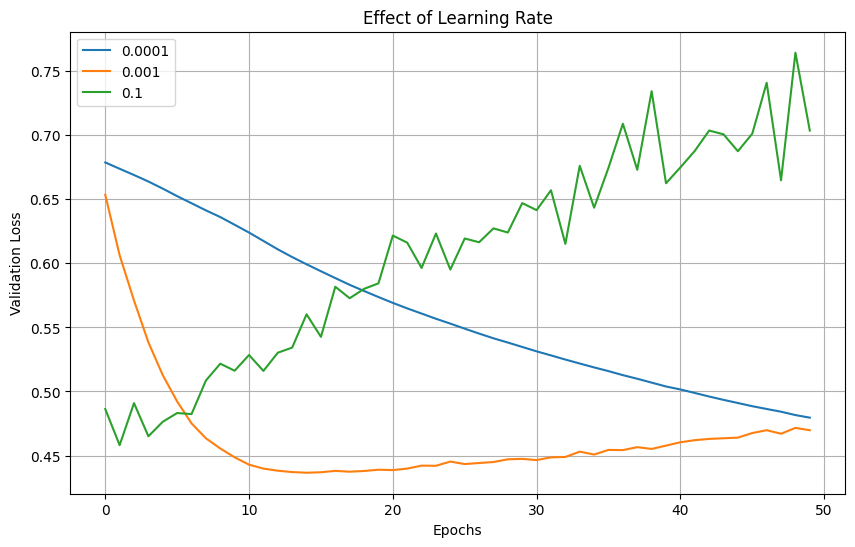

In [38]:
plt.figure(figsize=(10,6))

plt.plot(
    history_small_lr.history['val_loss'],
    label='0.0001'
)
plt.plot(
    history_medium_lr.history['val_loss'],
    label='0.001'
)
plt.plot(
    history_large_lr.history['val_loss'],
    label='0.1'
)

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True)

plt.show()

### Plotting Training History for All Models

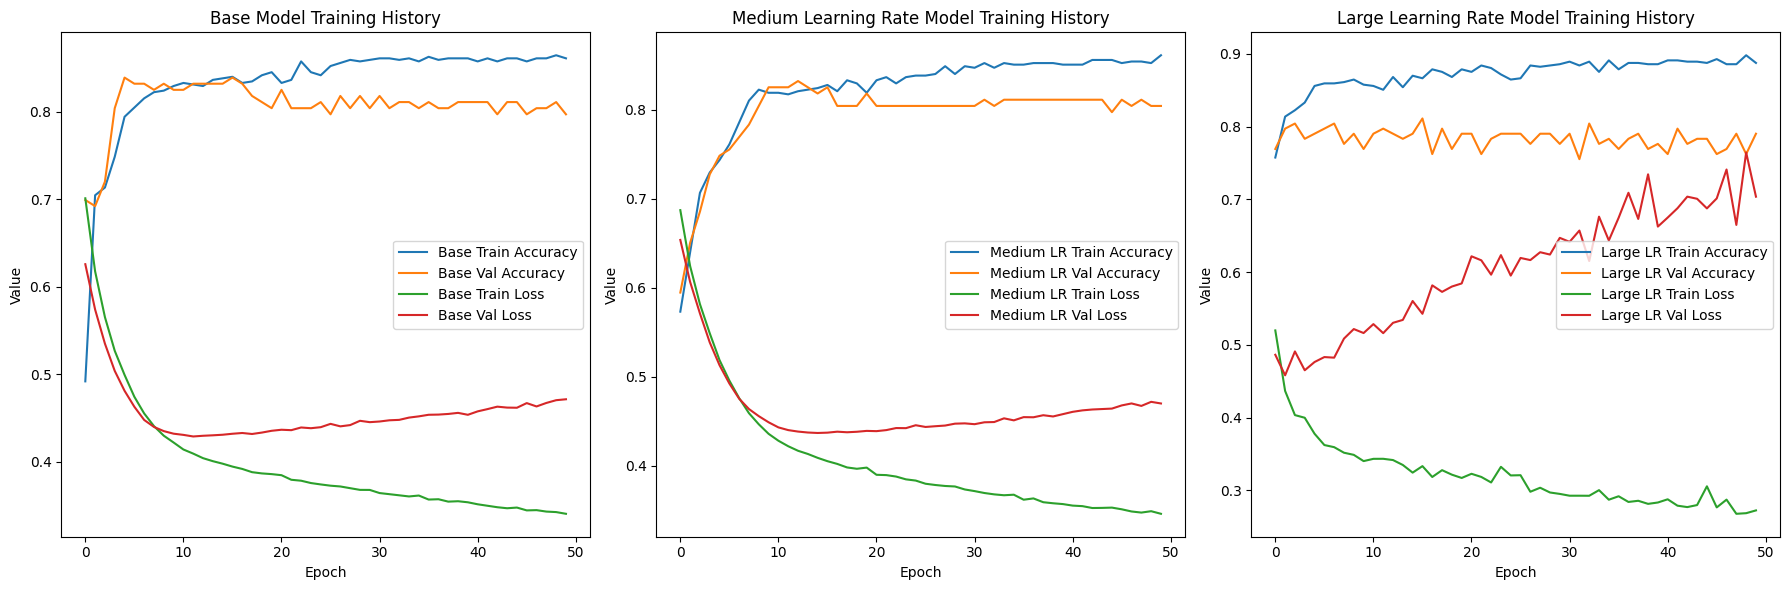

In [39]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(history_baseline.history['accuracy'], label='Base Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Base Val Accuracy')
plt.plot(history_baseline.history['loss'], label='Base Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Base Val Loss')
plt.title('Base Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_medium_lr.history['accuracy'], label='Medium LR Train Accuracy')
plt.plot(history_medium_lr.history['val_accuracy'], label='Medium LR Val Accuracy')
plt.plot(history_medium_lr.history['loss'], label='Medium LR Train Loss')
plt.plot(history_medium_lr.history['val_loss'], label='Medium LR Val Loss')
plt.title('Medium Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_large_lr.history['accuracy'], label='Large LR Train Accuracy')
plt.plot(history_large_lr.history['val_accuracy'], label='Large LR Val Accuracy')
plt.plot(history_large_lr.history['loss'], label='Large LR Train Loss')
plt.plot(history_large_lr.history['val_loss'], label='Large LR Val Loss')
plt.title('Large Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

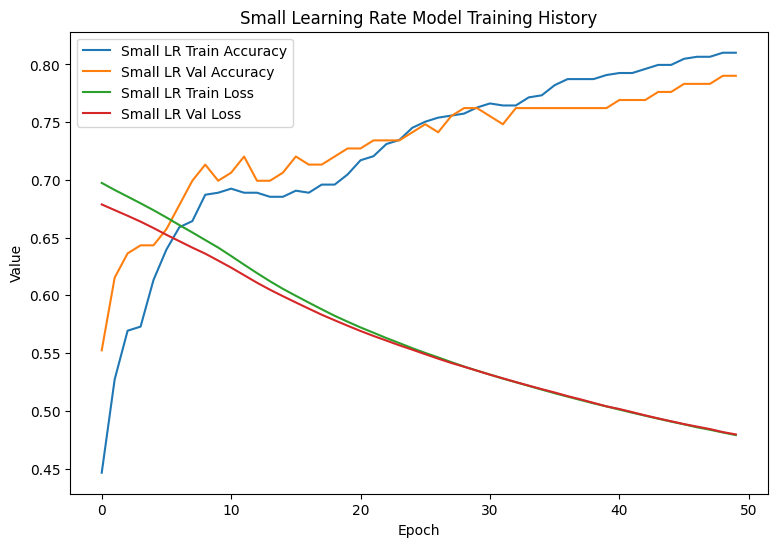

In [40]:
plt.figure(figsize=(9, 6))
plt.plot(history_small_lr.history['accuracy'], label='Small LR Train Accuracy')
plt.plot(history_small_lr.history['val_accuracy'], label='Small LR Val Accuracy')
plt.plot(history_small_lr.history['loss'], label='Small LR Train Loss')
plt.plot(history_small_lr.history['val_loss'], label='Small LR Val Loss')
plt.title('Small Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
# plt.tight_layout()
plt.show()

##Dropout model

In [41]:
drop_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [42]:
drop_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
history_dropout = drop_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6186 - loss: 0.6626 - val_accuracy: 0.7762 - val_loss: 0.6125
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7100 - loss: 0.6123 - val_accuracy: 0.7343 - val_loss: 0.5723
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7293 - loss: 0.5676 - val_accuracy: 0.7692 - val_loss: 0.5358
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7610 - loss: 0.5258 - val_accuracy: 0.7902 - val_loss: 0.5039
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7733 - loss: 0.5161 - val_accuracy: 0.7972 - val_loss: 0.4842
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7733 - loss: 0.4949 - val_accuracy: 0.8042 - val_loss: 0.4688
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7979 - loss: 0.4678 - val_accuracy: 0.8182 - val_loss: 0.4555
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7996 - loss: 0.4718 - val_accuracy: 0.8252 - val_loss

In [44]:
drop_loss,drop_accuracy = drop_model.evaluate(X_test, y_test)
print(f"Dropout Model Accuracy: {drop_accuracy}")
print(f"Dropout Model Loss: {drop_loss}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8045 - loss: 0.4542 
Dropout Model Accuracy: 0.8044692873954773
Dropout Model Loss: 0.4542255103588104


## Early Stoping in this drop_model

In [55]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [56]:
history = drop_model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8436 - loss: 0.3579 - val_accuracy: 0.8112 - val_loss: 0.4895
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8541 - loss: 0.3614 - val_accuracy: 0.8042 - val_loss: 0.4917
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8418 - loss: 0.3638 - val_accuracy: 0.8182 - val_loss: 0.4938
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8524 - loss: 0.3752 - val_accuracy: 0.8042 - val_loss: 0.4893
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8489 - loss: 0.3558 - val_accuracy: 0.8042 - val_loss: 0.4951
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8594 - loss: 0.3591 - val_accuracy: 0.8042 - val_loss: 0.4976
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8471 - loss: 0.3582 - val_accuracy: 0.8112 - val_loss: 0.5004
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8576 - loss: 0.3514 - val_accuracy: 0.

In [57]:
drop_loss,drop_accuracy = drop_model.evaluate(X_test, y_test)
print(f"Dropout Model Accuracy: {drop_accuracy}")
print(f"Dropout Model Loss: {drop_loss}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7989 - loss: 0.4541 
Dropout Model Accuracy: 0.7988826632499695
Dropout Model Loss: 0.4540866017341614


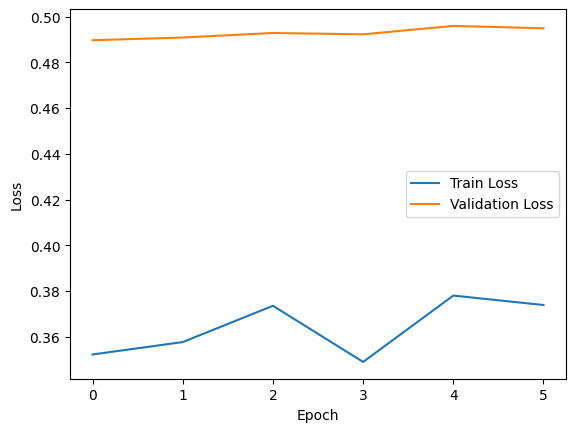

In [49]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

If performance of model is low :


1. Early Stoping
2. Dropout Method
3. L1,L2 Regularlization

Learned about creating sequrntial models using keras.sequrntial, used different datasets on the models and compared different models based on different learning rates and plotted different graphs of these models.